LOADING HAND GESTURE IMAGES

 Loading images... (wait 1-2 minutes)
 Images loaded  : 20000
 Labels loaded  : 20000
 Images shape   : (20000, 64, 64)
 Pixel range    : 0.0 to 1.0


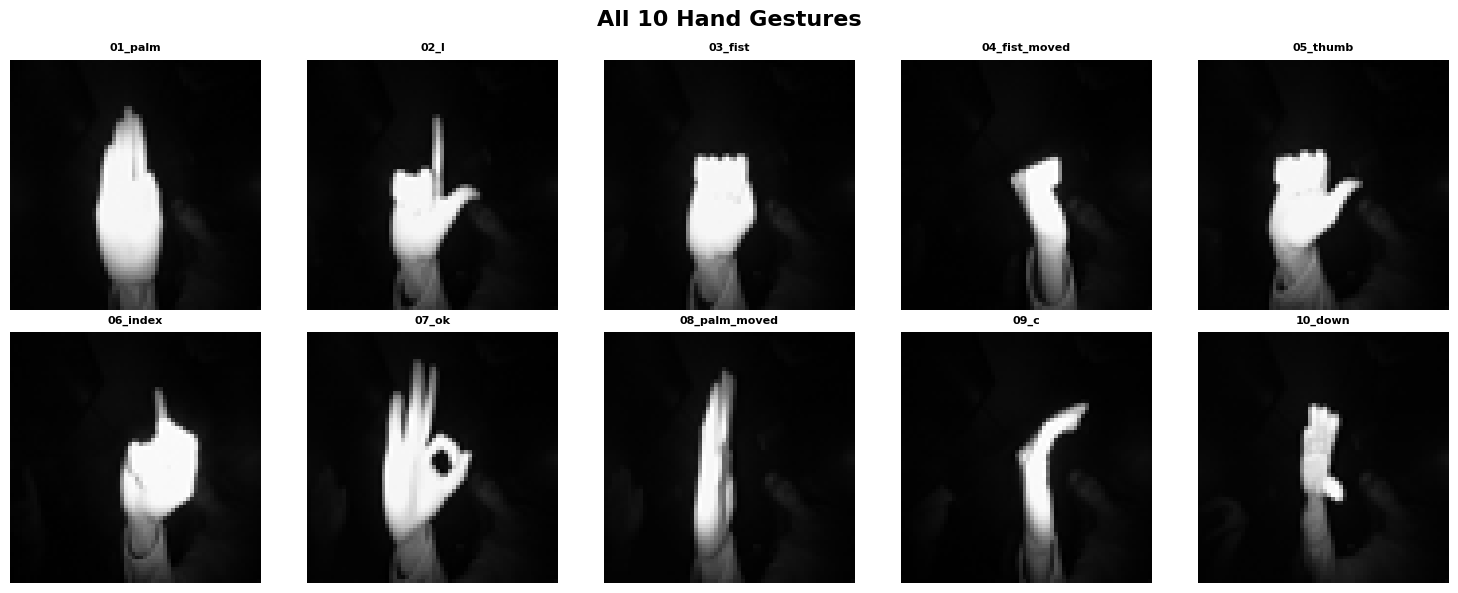


 Data saved → images.npy, labels.npy
 Ready for CNN Lesson 3!


In [6]:
import os
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

print("="*50)
print("LOADING HAND GESTURE IMAGES")
print("="*50)

# SETTINGS
DATASET_PATH = "/Users/apple/Desktop/Protfolio_project_CNN/leapGestRecog"
IMG_SIZE     = 64

gesture_labels = {
    "01_palm":       0,
    "02_l":          1,
    "03_fist":       2,
    "04_fist_moved": 3,
    "05_thumb":      4,
    "06_index":      5,
    "07_ok":         6,
    "08_palm_moved": 7,
    "09_c":          8,
    "10_down":       9
}

images = []
labels = []

print("\n Loading images... (wait 1-2 minutes)")

for subject in sorted(os.listdir(DATASET_PATH)):
    subject_path = os.path.join(DATASET_PATH, subject)
    if not os.path.isdir(subject_path):
        continue

    for gesture_name, label_number in gesture_labels.items():
        gesture_path = os.path.join(subject_path, gesture_name)
        if not os.path.isdir(gesture_path):
            continue

        for image_file in os.listdir(gesture_path):
            if not image_file.endswith(('.png','.jpg','.jpeg')):
                continue

            image_path = os.path.join(gesture_path, image_file)
            img = Image.open(image_path)
            img = img.convert("L")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img_array = np.array(img)
            images.append(img_array)
            labels.append(label_number)

images = np.array(images)
labels = np.array(labels)

# Normalise
images = images / 255.0

print(f" Images loaded  : {len(images)}")
print(f" Labels loaded  : {len(labels)}")
print(f" Images shape   : {images.shape}")
print(f" Pixel range    : {images.min():.1f} to {images.max():.1f}")

# Show sample images
gesture_names = list(gesture_labels.keys())
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("All 10 Hand Gestures", fontsize=16, fontweight="bold")
axes = axes.flatten()

for i in range(10):
    idx = np.where(labels == i)[0][0]
    axes[i].imshow(images[idx], cmap="gray")
    axes[i].set_title(f"{gesture_names[i]}", fontsize=8, fontweight="bold")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Save data
np.save("images.npy", images)
np.save("labels.npy", labels)

print("\n Data saved → images.npy, labels.npy")
print(" Ready for CNN Lesson 3!")

In [7]:
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

print("="*50)
print("BUILDING CNN MODEL")
print("="*50)

# LOAD SAVED DATA
images = np.load("images.npy")
labels = np.load("labels.npy")
print(f" Data loaded: {images.shape}")

# RESHAPE FOR CNN 
# CNN needs 4D input: (samples, height, width, channels)
# We add "1" for greyscale channel
images = images.reshape(-1, 64, 64, 1)
print(f" Reshaped: {images.shape}")

# SPLIT TRAIN / TEST 
# 80% training → CNN learns from these
# 20% testing  → we check how well it learned
X_train, X_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"\n Data Split:")
print(f"   Training : {X_train.shape[0]} images")
print(f"   Testing  : {X_test.shape[0]} images")

# BUILD CNN 
print("\n Building CNN architecture...")

model = models.Sequential([

    # Block 1 → find basic edges
    layers.Conv2D(32, (3,3), activation="relu",
                  input_shape=(64,64,1)),
    layers.MaxPooling2D(2,2),

    # Block 2 → find shapes
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Block 3 → find complex patterns
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Flatten → convert 2D to 1D
    layers.Flatten(),

    # Dropout → prevent memorising
    layers.Dropout(0.5),

    # Dense → combine patterns
    layers.Dense(128, activation="relu"),

    # Output → which gesture? (0-9)
    layers.Dense(10, activation="softmax")
])

# COMPILE 
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

BUILDING CNN MODEL


 Data loaded: (20000, 64, 64)
 Reshaped: (20000, 64, 64, 1)

 Data Split:
   Training : 16000 images
   Testing  : 4000 images

 Building CNN architecture...
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 62, 62, 32)        320       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 31, 31, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)          

In [8]:
print("="*50)
print("TRAINING CNN MODEL")
print("="*50)
print(" Training started... (5-10 minutes on CPU)")
print("Watch accuracy improve each epoch!\n")

# TRAIN THE MODEL
# epochs = how many times CNN sees ALL training images
# Like reading a textbook 10 times!

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\n Training complete!")

TRAINING CNN MODEL
 Training started... (5-10 minutes on CPU)
Watch accuracy improve each epoch!

Epoch 1/10
400/400 [==============================] - 107s 263ms/step - loss: 0.3459 - accuracy: 0.8839 - val_loss: 0.0176 - val_accuracy: 0.9941
Epoch 2/10
400/400 [==============================] - 111s 277ms/step - loss: 0.0246 - accuracy: 0.9927 - val_loss: 0.0113 - val_accuracy: 0.9978
Epoch 3/10
400/400 [==============================] - 111s 275ms/step - loss: 0.0100 - accuracy: 0.9966 - val_loss: 0.0108 - val_accuracy: 0.9972
Epoch 4/10
400/400 [==============================] - 105s 261ms/step - loss: 0.0071 - accuracy: 0.9978 - val_loss: 0.0575 - val_accuracy: 0.9825
Epoch 5/10
400/400 [==============================] - 120s 299ms/step - loss: 0.0105 - accuracy: 0.9967 - val_loss: 0.0080 - val_accuracy: 0.9987
Epoch 6/10
400/400 [==============================] - 136s 339ms/step - loss: 0.0116 - accuracy: 0.9963 - val_loss: 0.0055 - val_accuracy: 0.9994
Epoch 7/10
400/400 [======

EVALUATING CNN MODEL



 Test Accuracy : 99.83%
 Test Loss     : 0.0120


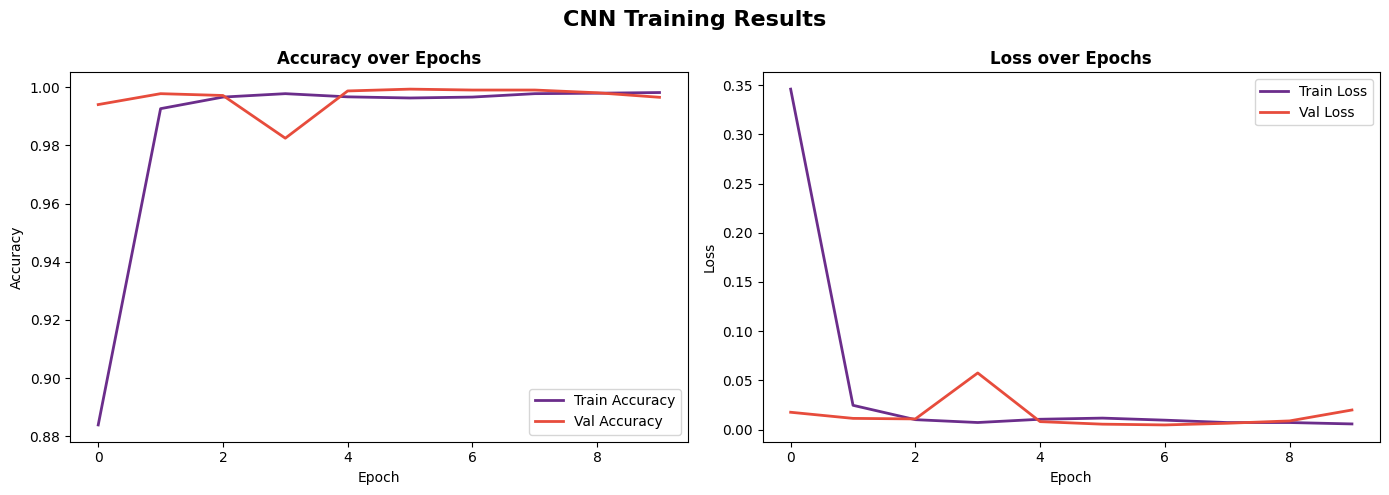


 Model saved → gesture_model.h5
 CNN Project Complete!


In [9]:
print("="*50)
print("EVALUATING CNN MODEL")
print("="*50)

# Test on images CNN has NEVER seen before!
test_loss, test_accuracy = model.evaluate(
    X_test, y_test, verbose=0
)

print(f"\n Test Accuracy : {test_accuracy*100:.2f}%")
print(f" Test Loss     : {test_loss:.4f}")

# Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN Training Results", fontsize=16, fontweight="bold")

# Accuracy chart
axes[0].plot(history.history["accuracy"],
             label="Train Accuracy", color="#6B2D8B", linewidth=2)
axes[0].plot(history.history["val_accuracy"],
             label="Val Accuracy", color="#E74C3C", linewidth=2)
axes[0].set_title("Accuracy over Epochs", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss chart
axes[1].plot(history.history["loss"],
             label="Train Loss", color="#6B2D8B", linewidth=2)
axes[1].plot(history.history["val_loss"],
             label="Val Loss", color="#E74C3C", linewidth=2)
axes[1].set_title("Loss over Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# Save model
model.save("gesture_model.h5")
print("\n Model saved → gesture_model.h5")
print(" CNN Project Complete!")